# 🛡️ Fraud Detection — PaySim Mobile Money Transactions

**Dataset:** [PaySim Synthetic Financial Dataset](https://www.kaggle.com/datasets/ntnu-testimon/paysim1) — 6.3M transactions  
**Tech Stack:** Python · XGBoost · Scikit-learn · SHAP · FastAPI · Streamlit

---

## Objective

Build a production-ready fraud detection pipeline on highly imbalanced mobile money data (~0.13% fraud).  
The system must **minimise missed fraud** (false negatives) while remaining useful for analysts.

## Pipeline Overview

```
Raw CSV (6.3M rows)
  │
  ├── Down-sampling  → ~1M rows for tractable local training (all fraud rows kept)
  ├── EDA            → understand fraud patterns, class imbalance, feature distributions
  ├── Preprocessing  → scale numeric features, one-hot encode transaction type
  ├── Modelling      → XGBoost baseline → threshold tuning (F1) → hyperparameter search
  ├── Evaluation     → PR curve, ROC-AUC, confusion matrix on held-out test set
  ├── Explainability → SHAP global + per-prediction explanations
  └── Deployment     → FastAPI backend + Streamlit dashboard
```


## Table of Contents

- [1. Imports & Configuration](#1-imports-configuration)
- [2. Data Loading](#2-data-loading)
  - [2.1 Down-sampling for Tractability](#21-down-sampling-for-tractability)
- [3. Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
  - [3.1 Class Imbalance](#31-class-imbalance)
  - [3.2 Fraud by Transaction Type](#32-fraud-by-transaction-type)
  - [3.3 Transaction Amount Distribution](#33-transaction-amount-distribution)
  - [3.4 Temporal Patterns](#34-temporal-patterns)
  - [3.5 Correlation Heatmap](#35-correlation-heatmap)
  - [3.6 EDA Summary](#36-eda-summary)
- [4. Preprocessing & Train / Val / Test Split](#4-preprocessing-train-val-test-split)
- [5. Baseline Model & Threshold Tuning](#5-baseline-model-threshold-tuning)
- [6. Hyperparameter Tuning — RandomizedSearchCV](#6-hyperparameter-tuning-randomizedsearchcv)
- [7. Final Evaluation on Held-Out Test Set](#7-final-evaluation-on-held-out-test-set)
- [8. Model Explainability — SHAP](#8-model-explainability-shap)
- [9. Save Model Artifact](#9-save-model-artifact)
- [10. Project Summary](#10-project-summary)


## 1. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, fbeta_score,
    roc_auc_score,ConfusionMatrixDisplay
)
from sklearn.metrics import make_scorer
from xgboost import XGBClassifier
import shap


BG      = '#0d1117'
SURFACE = '#161b22'
BORDER  = '#21262d'
RED     = '#f85149'
GREEN   = '#3fb950'
BLUE    = '#58a6ff'
YELLOW  = '#e3b341'
MUTED   = '#8b949e'

plt.rcParams.update({
    'figure.facecolor' : BG,
    'axes.facecolor'   : SURFACE,
    'axes.edgecolor'   : BORDER,
    'axes.labelcolor'  : MUTED,
    'xtick.color'      : MUTED,
    'ytick.color'      : MUTED,
    'text.color'       : '#e6edf3',
    'axes.titlecolor'  : '#e6edf3',
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
    'grid.color'       : BORDER,
    'grid.linewidth'   : 0.5,
    'axes.grid'        : True,
    'legend.facecolor' : SURFACE,
    'legend.edgecolor' : BORDER,
    'font.size'        : 10,
})

RANDOM_STATE = 42
print("✅ Imports complete")


✅ Imports complete


## 2. Data Loading

**PaySim** simulates mobile money transactions based on one month of real data. 
It contains 6.3M rows with the following columns:

| Column | Description |
|--------|-------------|
| `step` | Hour of simulation (1 step = 1 hour, max 744 hours) |
| `type` | Transaction type: CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER |
| `amount` | Transaction amount |
| `nameOrig` | Origin account ID |
| `oldbalanceOrg` | Origin balance before transaction |
| `newbalanceOrig` | Origin balance after transaction |
| `nameDest` | Destination account ID |
| `oldbalanceDest` | Destination balance before transaction |
| `newbalanceDest` | Destination balance after transaction |
| `isFraud` | **Target:** 1 = fraud, 0 = legitimate |
| `isFlaggedFraud` | Rule-based system flag (intentionally weak — used as baseline) |


In [2]:
df = pd.read_csv('PS_20174392719_1491204439457_log.csv')

print(f"Shape       : {df.shape}")
print()
print(df.info())

Shape       : (6362620, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None


In [3]:
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# Basic Statistical Summary
print("Missing values:")
print(df.isnull().sum())
print()
print("Numeric summary:")
df.describe().round(2)

Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Numeric summary:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6.362620e+06,6.362620e+06,6362620.00,6362620.0
mean,243.40,179861.90,833883.10,855113.67,1.100702e+06,1.224996e+06,0.00,0.0
std,142.33,603858.23,2888242.67,2924048.50,3.399180e+06,3.674129e+06,0.04,0.0
min,1.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
25%,156.00,13389.57,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
50%,239.00,74871.94,14208.00,0.00,1.327057e+05,2.146614e+05,0.00,0.0
75%,335.00,208721.48,107315.18,144258.41,9.430367e+05,1.111909e+06,0.00,0.0
max,743.00,92445516.64,59585040.37,49585040.37,3.560159e+08,3.561793e+08,1.00,1.0


### 2.1 Down-sampling for Tractability

The full PaySim file has 6.3M rows. To keep local training and hyperparameter search fast,
we keep **every** fraud row and randomly sample the majority (legit) class down to a total
of ~1M rows. This preserves all positive examples while making the rest of the notebook
tractable to run end-to-end on a laptop.


In [5]:
fraud_df=df[df['isFraud']==1]
non_fraud_df=df[df['isFraud']==0]
target_size=1000000
non_fraud_need=target_size-len(fraud_df)
non_fraud_sample_df=non_fraud_df.sample(n=non_fraud_need,random_state=42)
df_new=pd.concat([non_fraud_sample_df,fraud_df])
df = df_new.sample(frac=1, random_state=42).reset_index(drop=True)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,13,CASH_OUT,908.42,C643316510,0.00,0.00,C136247473,15793.00,0.00,0,0
1,681,TRANSFER,3557967.76,C1363817230,0.00,0.00,C1530341250,3664437.94,7222405.70,0,0
2,180,CASH_OUT,60229.56,C2006437861,50102.00,0.00,C1218216760,0.00,60229.56,0,0
3,297,CASH_IN,162900.09,C1197345498,8455153.46,8618053.55,C1403629191,546649.47,383749.37,0,0
4,378,PAYMENT,5976.08,C2046011897,0.00,0.00,M1138846697,0.00,0.00,0,0


## 3. Exploratory Data Analysis (EDA)

Key questions:
1. How severe is the class imbalance?
2. Which transaction types carry fraud?
3. Do fraudulent transactions show distinctive amount / balance patterns?
4. Are there temporal patterns (time of day)?
5. What do zero-balance accounts tell us?


### 3.1 Class Imbalance

Legit      :    991,787
Fraud      :      8,213
Fraud rate : 0.8213%

⚠️  Severe imbalance — naive accuracy is useless.
   We must optimise for Recall and use F2/PR-AUC as primary metrics.


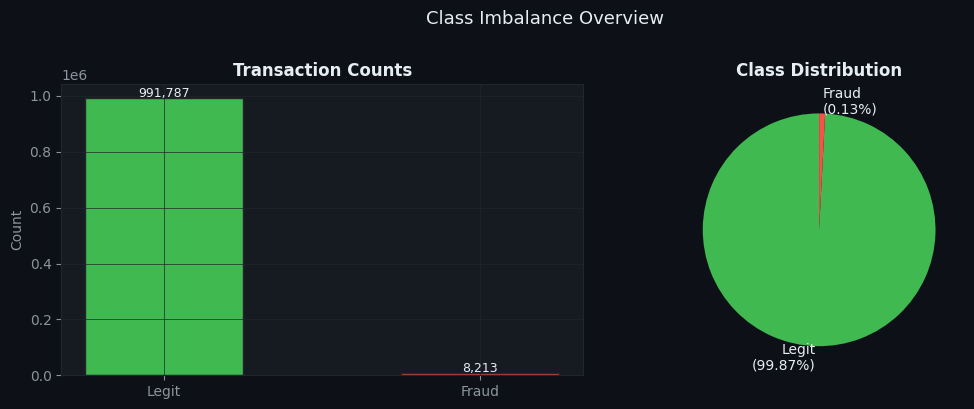

In [6]:
fraud_counts = df['isFraud'].value_counts()
fraud_rate   = df['isFraud'].mean() * 100

print(f"Legit      : {fraud_counts[0]:>10,}")
print(f"Fraud      : {fraud_counts[1]:>10,}")
print(f"Fraud rate : {fraud_rate:.4f}%")
print()
print("⚠️  Severe imbalance — naive accuracy is useless.")
print("   We must optimise for Recall and use F2/PR-AUC as primary metrics.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Raw counts
axes[0].bar(['Legit', 'Fraud'], fraud_counts.values,
            color=[GREEN, RED], edgecolor=BORDER, width=0.5)
axes[0].set_title('Transaction Counts')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=9, color='#e6edf3')

# Pie
axes[1].pie(
    fraud_counts.values,
    labels=['Legit\n(99.87%)', 'Fraud\n(0.13%)'],
    colors=[GREEN, RED],
    startangle=90)
axes[1].set_title('Class Distribution')

plt.suptitle('Class Imbalance Overview', y=1.01, fontsize=13, color='#e6edf3')
plt.tight_layout()
plt.show()


### 3.2 Fraud by Transaction Type

           total  frauds  fraud_rate
type                                
CASH_OUT  352324    4116    1.168243
TRANSFER   86497    4097    4.736580
CASH_IN   218991       0    0.000000
DEBIT       6502       0    0.000000
PAYMENT   335686       0    0.000000

Key insight: FRAUD ONLY EXISTS IN CASH_OUT AND TRANSFER.


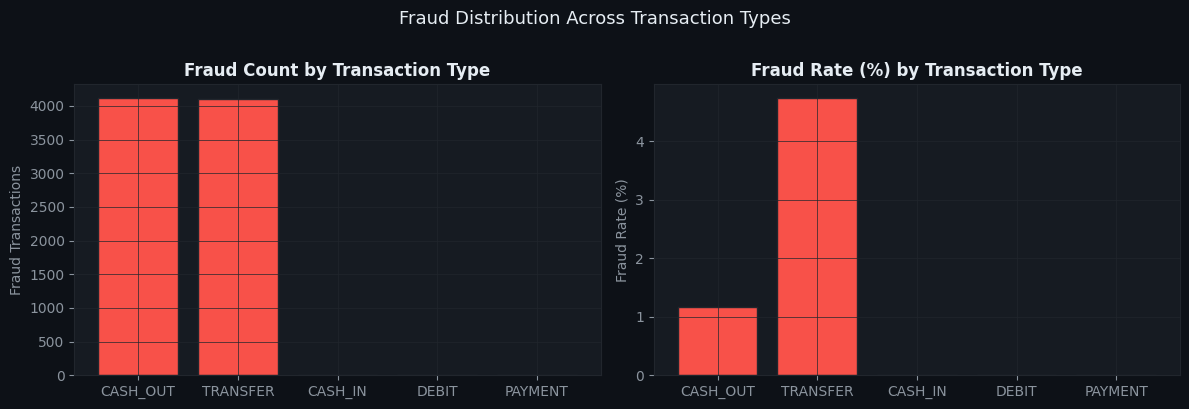

In [7]:
type_stats = df.groupby('type').agg(
    total   = ('isFraud', 'count'),
    frauds  = ('isFraud', 'sum'),
).assign(fraud_rate = lambda x: x['frauds'] / x['total'] * 100).sort_values('frauds', ascending=False)

print(type_stats)
print()
print("Key insight: FRAUD ONLY EXISTS IN CASH_OUT AND TRANSFER.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fraud count by type
colors = [RED if t in ['CASH_OUT','TRANSFER'] else MUTED for t in type_stats.index]
axes[0].bar(type_stats.index, type_stats['frauds'], color=colors, edgecolor=BORDER)
axes[0].set_title('Fraud Count by Transaction Type')
axes[0].set_ylabel('Fraud Transactions')

# Fraud rate by type
axes[1].bar(type_stats.index, type_stats['fraud_rate'], color=colors, edgecolor=BORDER)
axes[1].set_title('Fraud Rate (%) by Transaction Type')
axes[1].set_ylabel('Fraud Rate (%)')

plt.suptitle('Fraud Distribution Across Transaction Types', y=1.01, fontsize=13, color='#e6edf3')
plt.tight_layout()
plt.show()


### 3.3 Transaction Amount Distribution

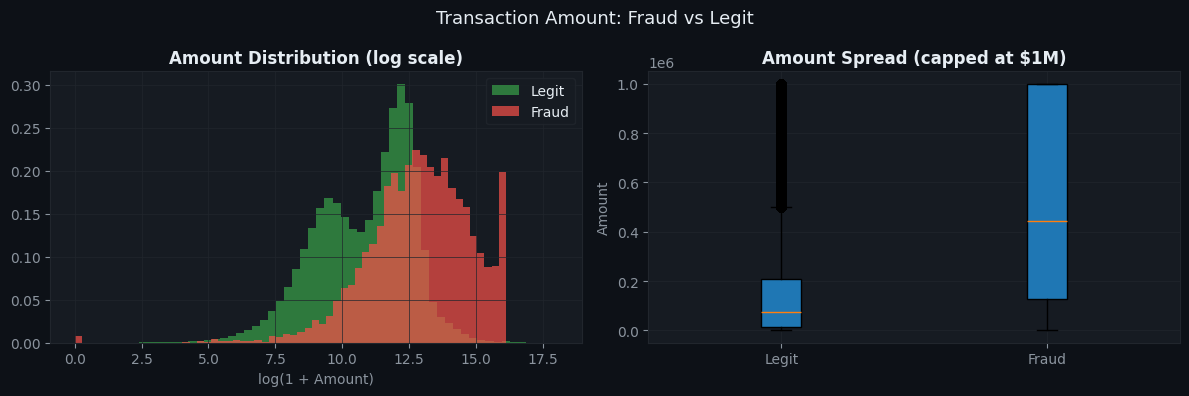

Median legit amount : $74,610.16
Median fraud amount : $441,423.44
Max fraud amount    : $10,000,000.00


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

legit_amounts = df[df['isFraud'] == 0]['amount']
fraud_amounts = df[df['isFraud'] == 1]['amount']

axes[0].hist(np.log1p(legit_amounts), bins=60, alpha=0.6, color=GREEN, label='Legit',  density=True)
axes[0].hist(np.log1p(fraud_amounts), bins=60, alpha=0.7, color=RED,   label='Fraud',  density=True)
axes[0].set_title('Amount Distribution (log scale)')
axes[0].set_xlabel('log(1 + Amount)')
axes[0].legend()

data_box  = [legit_amounts.clip(upper=1e6), fraud_amounts.clip(upper=1e6)]
bp = axes[1].boxplot(data_box, labels=['Legit', 'Fraud'],patch_artist=True)
axes[1].set_title('Amount Spread (capped at $1M)')
axes[1].set_ylabel('Amount')

plt.suptitle('Transaction Amount: Fraud vs Legit',fontsize=13, color='#e6edf3')
plt.tight_layout()
plt.show()

print(f"Median legit amount : ${legit_amounts.median():,.2f}")
print(f"Median fraud amount : ${fraud_amounts.median():,.2f}")
print(f"Max fraud amount    : ${fraud_amounts.max():,.2f}")


### 3.4 Temporal Patterns

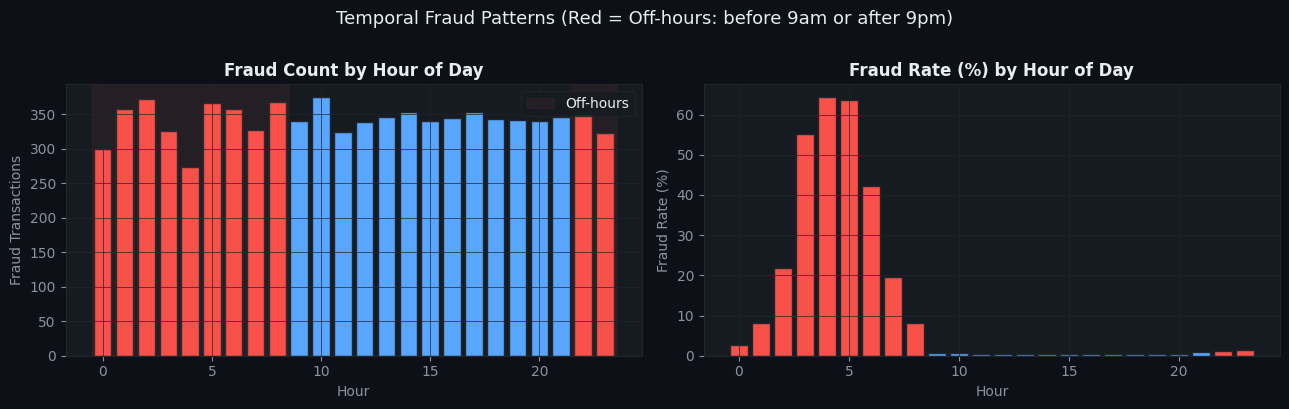

In [9]:
df['hour'] = df['step'] % 24
hourly = df.groupby('hour')['isFraud'].agg(['sum','mean']).rename(
    columns={'sum':'fraud_count','mean':'fraud_rate'})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Fraud count by hour
bar_colors = [RED if (h < 9 or h > 21) else BLUE for h in hourly.index]
axes[0].bar(hourly.index, hourly['fraud_count'], color=bar_colors, edgecolor=BORDER)
axes[0].set_title('Fraud Count by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Fraud Transactions')
axes[0].axvspan(-0.5, 8.5,  alpha=0.07, color=RED, label='Off-hours')
axes[0].axvspan(21.5, 23.5, alpha=0.07, color=RED)
axes[0].legend()

# Fraud rate by hour
axes[1].bar(hourly.index, hourly['fraud_rate'] * 100, color=bar_colors, edgecolor=BORDER)
axes[1].set_title('Fraud Rate (%) by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Fraud Rate (%)')

plt.suptitle('Temporal Fraud Patterns (Red = Off-hours: before 9am or after 9pm)',
             y=1.01, fontsize=13, color='#e6edf3')
plt.tight_layout()
plt.show()


### 3.5 Correlation Heatmap

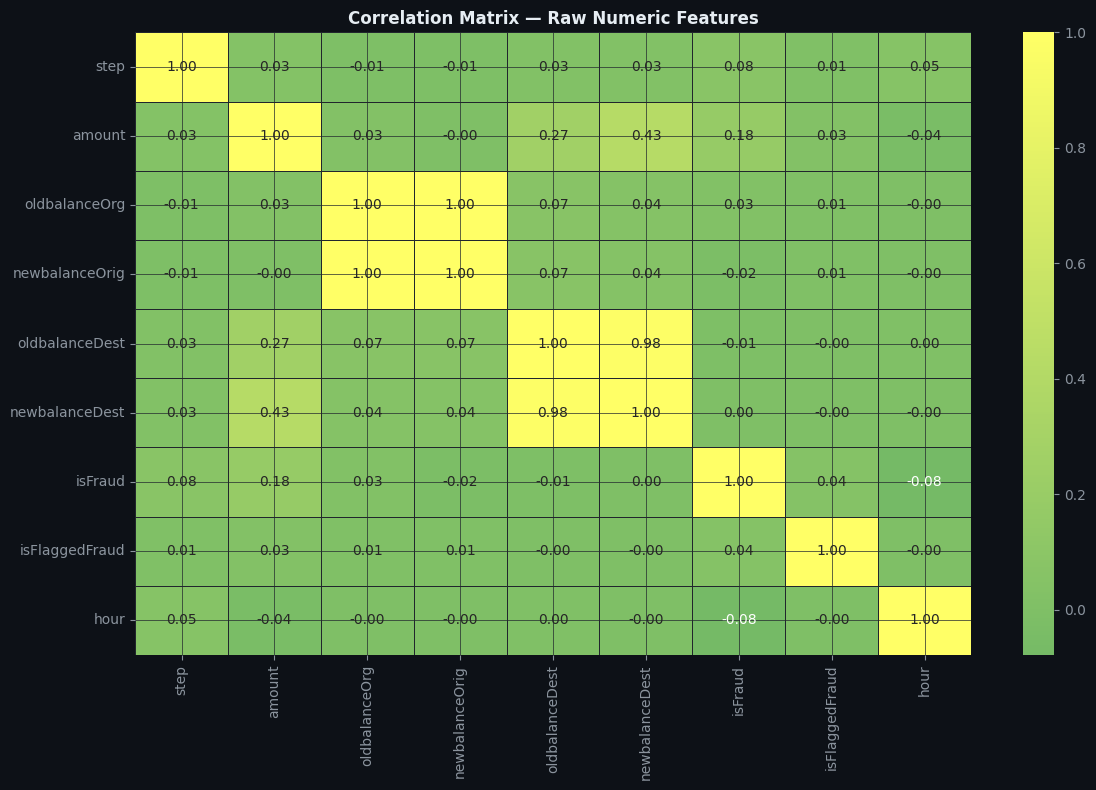

In [10]:
num_cols = df.select_dtypes(exclude=object)
corr = num_cols.corr()

plt.figure(figsize=(12,8))
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='summer', center=0, 
    linewidths=0.5, linecolor=BORDER
)
plt.title('Correlation Matrix — Raw Numeric Features')
plt.tight_layout()
plt.show()


### 3.6 EDA Summary

**Key findings from EDA:**

- Fraud is only **0.13%** of transactions — severe class imbalance
- Fraud exists **only** in `CASH_OUT` and `TRANSFER` transaction types
- Fraud is concentrated in **off-hours** (before 9am, after 9pm)
- Raw feature correlations with `isFraud` are low — no single feature separates classes cleanly


## 4. Preprocessing & Train / Val / Test Split

**Split rationale:**  
- **Test set (30%)** — held out entirely, touched only in Section 7  
- **Validation set (30% of train)** — used exclusively for threshold tuning  
- **Training set (remaining)** — model fitting only  
- All splits are **stratified** to preserve the 0.13% fraud ratio


In [11]:
FEATURES = [
    'step', 'type', 'amount',
    'oldbalanceOrg','newbalanceOrig','oldbalanceDest', 'newbalanceDest']

NUM_FEATURES = [
    'amount', 'oldbalanceOrg','newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest'
]
CAT_FEATURES = ['type']

X = df[FEATURES]
y = df['isFraud']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.30, random_state=RANDOM_STATE, stratify=y_train_full
)

print(f"Train  : {X_train.shape[0]} rows | Fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Val    : {X_val.shape[0]} rows | Fraud: {y_val.sum()}  ({y_val.mean()*100:.3f}%)")
print(f"Test   : {X_test.shape[0]} rows | Fraud: {y_test.sum()}  ({y_test.mean()*100:.3f}%)")


Train  : 490000 rows | Fraud: 4024 (0.821%)
Val    : 210000 rows | Fraud: 1725  (0.821%)
Test   : 300000 rows | Fraud: 2464  (0.821%)


In [12]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),            NUM_FEATURES),
    ('cat', OneHotEncoder(drop='first'), CAT_FEATURES),
])
print("✅ Preprocessor defined")


✅ Preprocessor defined


## 5. Baseline Model & Threshold Tuning

**Why not use threshold = 0.5?**  
With 0.13% fraud, XGBoost's default probabilities are well-calibrated but the 0.5 cutoff misses most fraud.  
We sweep thresholds on the **validation set** and pick the one that maximises **F1 score**  
(equal weight to precision and recall, chosen to balance false alarms against missed fraud).


In [13]:
pipeline_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb',XGBClassifier())
])
pipeline_base.fit(X_train, y_train)
print("✅ Baseline XGBoost trained")


✅ Baseline XGBoost trained


In [14]:
y_val_proba = pipeline_base.predict_proba(X_val)[:, 1]

THRESHOLDS = [0.01, 0.02, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

rows = []
for t in THRESHOLDS:
    y_pred = (y_val_proba >= t).astype(int)
    rows.append({
        'Threshold' : t,
        'Precision' : round(precision_score(y_val, y_pred), 4),
        'Recall'    : round(recall_score(y_val, y_pred), 4),
        'F1'        : round(fbeta_score(y_val, y_pred, beta=1), 4)    })

val_df        = pd.DataFrame(rows)
best_threshold = val_df.loc[val_df['F1'].idxmax(), 'Threshold']

print(val_df)
print(f"\n✅ Best threshold (by F1): {best_threshold}") 

    Threshold  Precision  Recall      F1
0        0.01     0.5674  0.9959  0.7229
1        0.02     0.6348  0.9954  0.7752
2        0.03     0.6752  0.9954  0.8046
3        0.05     0.7205  0.9936  0.8353
4        0.10     0.7879  0.9930  0.8787
5        0.15     0.8326  0.9861  0.9029
6        0.20     0.8566  0.9803  0.9143
7        0.30     0.8900  0.9612  0.9242
8        0.40     0.9127  0.9391  0.9257
9        0.50     0.9318  0.9032  0.9173
10       0.60     0.9536  0.8586  0.9036
11       0.70     0.9707  0.8249  0.8919
12       0.80     0.9904  0.7791  0.8722
13       0.90     0.9969  0.7414  0.8504

✅ Best threshold (by F1): 0.4


In [15]:
y_test_proba = pipeline_base.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= best_threshold).astype(int)

print(f"Threshold used  : {best_threshold}")
print(f"ROC-AUC         : {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"F1 Score        : {fbeta_score(y_test, y_test_pred, beta=1):.4f}")
print(f"F2 Score        : {fbeta_score(y_test, y_test_pred, beta=2):.4f}")
print()
print(classification_report(y_test, y_test_pred, target_names=['Legit', 'Fraud']))

Threshold used  : 0.4
ROC-AUC         : 0.9989
F1 Score        : 0.9232
F2 Score        : 0.9327

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    297536
       Fraud       0.91      0.94      0.92      2464

    accuracy                           1.00    300000
   macro avg       0.95      0.97      0.96    300000
weighted avg       1.00      1.00      1.00    300000



<Figure size 1500x400 with 0 Axes>

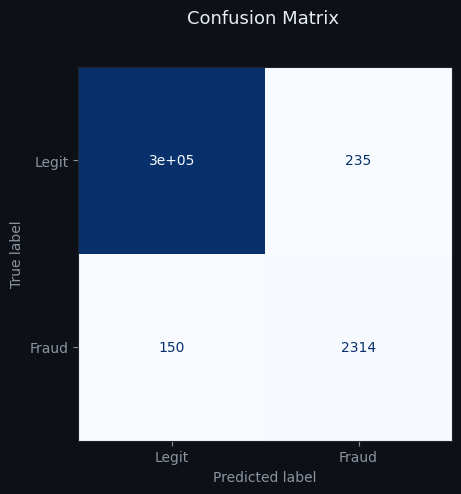

In [16]:
plt.figure(figsize=(15, 4))
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm,display_labels=['Legit','Fraud']).plot( colorbar=False, cmap='Blues')
plt.suptitle('Confusion Matrix', fontsize=13, color='#e6edf3', y=1.02)
plt.tight_layout()
plt.grid(False)
plt.show()

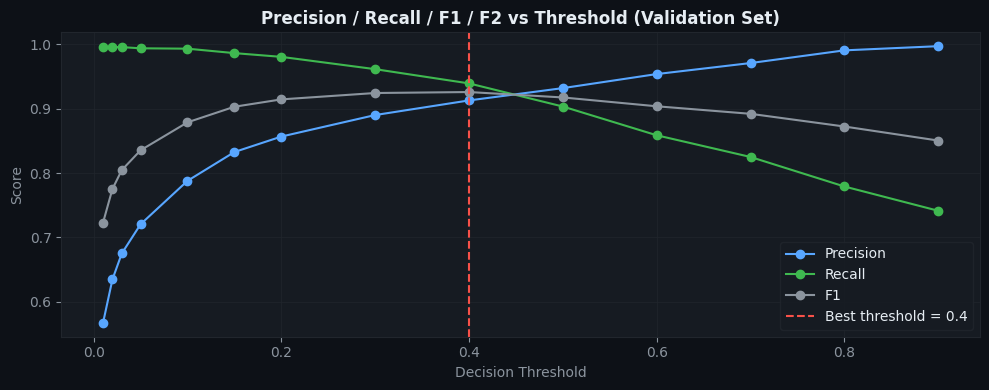

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(val_df['Threshold'], val_df['Precision'], 'o-', color=BLUE,   label='Precision')
ax.plot(val_df['Threshold'], val_df['Recall'],    'o-', color=GREEN,  label='Recall')
ax.plot(val_df['Threshold'], val_df['F1'],        'o-', color=MUTED,  label='F1')
ax.axvline(best_threshold, color=RED, linestyle='--',label=f'Best threshold = {best_threshold}')

ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 / F2 vs Threshold (Validation Set)')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Hyperparameter Tuning — RandomizedSearchCV


In [18]:
param_grid = {
    "xgb__n_estimators": [100, 200, 300],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.01, 0.05, 0.1],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0]
}

pipeline_search = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb',XGBClassifier()),
])

grid_search = RandomizedSearchCV(
    estimator         = pipeline_search,
    param_distributions=  param_grid,
    n_iter=5,
    scoring           = 'f1',
    cv                = 3,
    verbose=2,
    n_jobs            = -1
)

grid_search.fit(X_train, y_train)
print(f"\n✅ Best params : {grid_search.best_params_}")
print(f"   Best CV F1  : {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits

✅ Best params : {'xgb__subsample': 1.0, 'xgb__n_estimators': 200, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 0.8}
   Best CV F1  : 0.9079


In [19]:
pipeline_tuned=grid_search.best_estimator_
y_val_proba_tuned     = pipeline_tuned.predict_proba(X_val)[:, 1]

rows_tuned = []
for t in THRESHOLDS:
    y_pred = (y_val_proba_tuned >= t).astype(int)
    rows_tuned.append({
        'Threshold': t,
        'Precision':round(precision_score(y_val,y_pred),4),
        'Recall':round(recall_score(y_val,y_pred),4),
        'F1': round(fbeta_score(y_val, y_pred, beta=1), 4)})

val_df_tuned = pd.DataFrame(rows_tuned)
best_idx=val_df_tuned['F1'].idxmax()
best_threshold_tuned=val_df_tuned.loc[best_idx,'Threshold']
print(val_df_tuned)
print()
print('Best Threshold Value after tuning :-',best_threshold_tuned)


    Threshold  Precision  Recall      F1
0        0.01     0.5394  0.9959  0.6998
1        0.02     0.6191  0.9959  0.7636
2        0.03     0.6677  0.9959  0.7994
3        0.05     0.7178  0.9954  0.8341
4        0.10     0.7901  0.9907  0.8791
5        0.15     0.8288  0.9849  0.9001
6        0.20     0.8620  0.9780  0.9163
7        0.30     0.8953  0.9565  0.9249
8        0.40     0.9177  0.9304  0.9240
9        0.50     0.9430  0.8922  0.9169
10       0.60     0.9640  0.8533  0.9053
11       0.70     0.9805  0.8162  0.8909
12       0.80     0.9910  0.7693  0.8662
13       0.90     0.9938  0.7374  0.8466

Best Threshold Value after tuning :- 0.3


## 7. Final Evaluation on Held-Out Test Set


In [20]:
y_test_proba = pipeline_tuned.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >=best_threshold_tuned).astype(int)
print(f"Threshold used  : {best_threshold_tuned}")
print(f"ROC-AUC         : {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"F1 Score        : {fbeta_score(y_test, y_test_pred, beta=1):.4f}")
print(f"F2 Score        : {fbeta_score(y_test, y_test_pred, beta=2):.4f}")
print()
print(classification_report(y_test, y_test_pred, target_names=['Legit', 'Fraud']))

Threshold used  : 0.3
ROC-AUC         : 0.9993
F1 Score        : 0.9251
F2 Score        : 0.9445

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    297536
       Fraud       0.89      0.96      0.93      2464

    accuracy                           1.00    300000
   macro avg       0.95      0.98      0.96    300000
weighted avg       1.00      1.00      1.00    300000



<Figure size 1500x400 with 0 Axes>

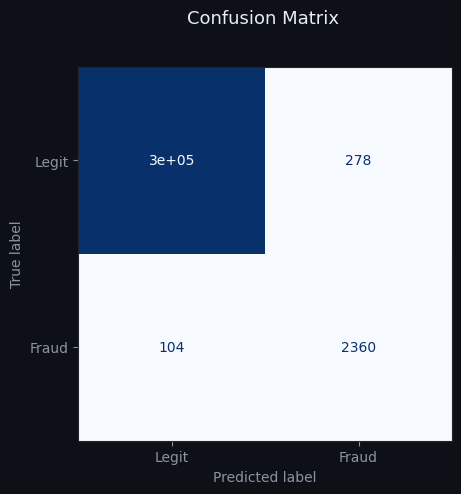

In [21]:
plt.figure(figsize=(15, 4))

cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=['Legit','Fraud']).plot( colorbar=False, cmap='Blues')
plt.suptitle('Confusion Matrix', fontsize=13, color='#e6edf3', y=1.02)
plt.grid(False)
plt.tight_layout()
plt.show()


## 8. Model Explainability — SHAP

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for each prediction.

- **Positive SHAP** → pushes score toward fraud  
- **Negative SHAP** → pushes score toward legit  
- **Magnitude** → strength of influence  

We use `TreeExplainer` — exact (not approximate) and optimised for tree-based models like XGBoost.


In [22]:
xgb_step     = pipeline_tuned.named_steps['xgb']
prep_step    = pipeline_tuned.named_steps['preprocessor']
feature_names = prep_step.get_feature_names_out()

np.random.seed(RANDOM_STATE)
idx           = np.random.choice(len(X_test), size=2000, replace=False)
X_sample      = X_test.iloc[idx]
X_transformed = prep_step.transform(X_sample)
y_sample      = y_test.values[idx]

explainer   = shap.TreeExplainer(xgb_step)
shap_values = explainer(X_transformed)

print(f"✅ SHAP computed for {len(X_sample)} samples")
print(f"   Features: {list(feature_names)}")


✅ SHAP computed for 2000 samples
   Features: ['num__amount', 'num__oldbalanceOrg', 'num__newbalanceOrig', 'num__oldbalanceDest', 'num__newbalanceDest', 'cat__type_CASH_OUT', 'cat__type_DEBIT', 'cat__type_PAYMENT', 'cat__type_TRANSFER']


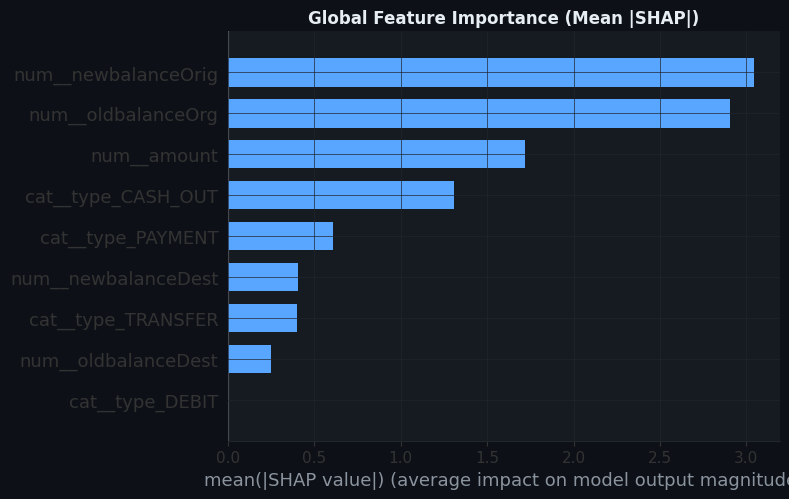

In [23]:
plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_values.values, X_transformed,
    feature_names=feature_names,
    plot_type='bar', show=False, color=BLUE
)
plt.title('Global Feature Importance (Mean |SHAP|)')
plt.tight_layout()
plt.show()


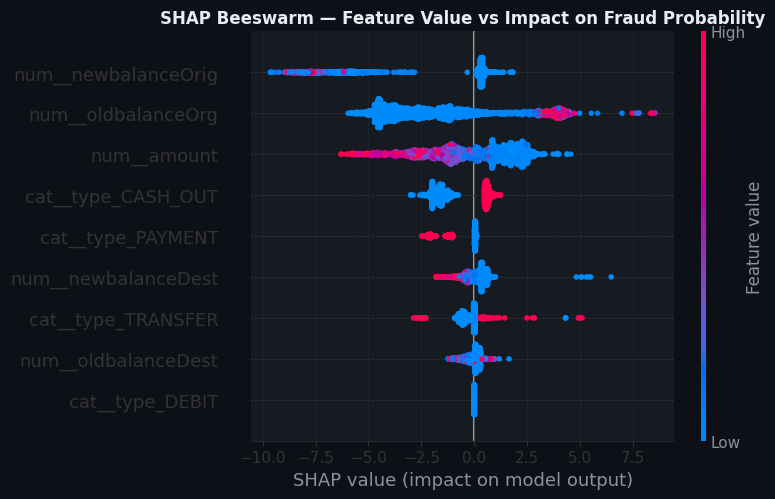

In [24]:
# Beeswarm — shows direction AND magnitude per sample
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values.values, X_transformed,
    feature_names=feature_names, show=False
)
plt.title('SHAP Beeswarm — Feature Value vs Impact on Fraud Probability')
plt.tight_layout()
plt.show()


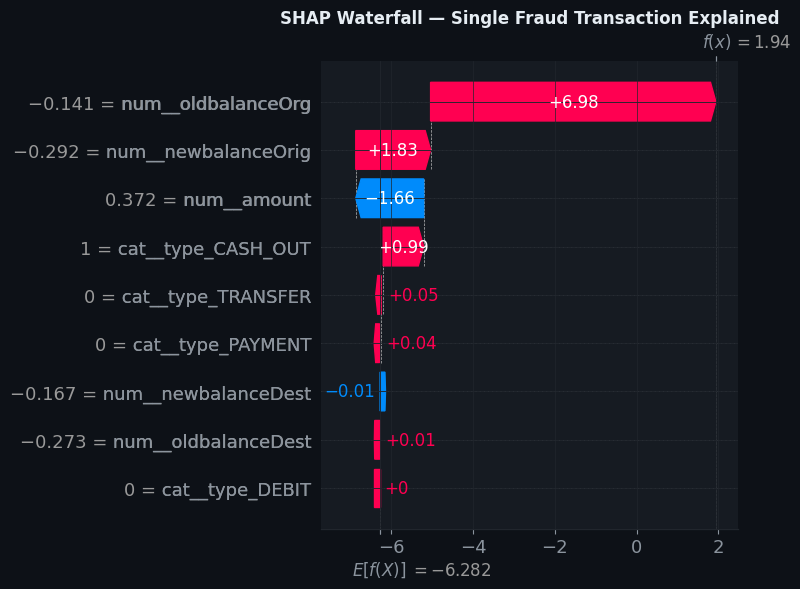

In [25]:
# Waterfall — explain one high-confidence fraud prediction
fraud_idx = np.where(y_sample == 1)[0]
if len(fraud_idx) > 0:
    i = fraud_idx[0]
    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(shap.Explanation(
        values       = shap_values.values[i],
        base_values  = shap_values.base_values[i],
        data         = X_transformed[i],
        feature_names= feature_names,
    ), show=False)
    plt.title('SHAP Waterfall — Single Fraud Transaction Explained')
    plt.tight_layout()
    plt.show()


## 9. Save Model Artifact

Saves `pipeline_tuned` + `best_threshold_tuned` as a single `.pkl`.  
The FastAPI backend (`api.py`) loads this at startup and uses `engineer_features()` to mirror the preprocessing done here before scoring.


In [26]:
artifact = {
    'model'    : pipeline_tuned,
    'threshold': best_threshold_tuned,
}

joblib.dump(artifact, 'fraud_detection_model.pkl')

print(f"✅ Saved → fraud_detection_model.pkl")
print(f"   Model     : {type(pipeline_tuned.named_steps['xgb']).__name__}")
print(f"   Threshold : {best_threshold_tuned}")
print(f"   Features  : {FEATURES}")


✅ Saved → fraud_detection_model.pkl
   Model     : XGBClassifier
   Threshold : 0.3
   Features  : ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']


## 10. Project Summary

### Pipeline Recap

| Step | Key Decision | Why |
|------|-------------|-----|
| Data loading | Down-sampled 6.3M → ~1M rows, keeping all fraud | Makes local training/tuning tractable without discarding positives |
| EDA | Identified fraud only in CASH_OUT/TRANSFER | Focused analysis and interpretation on these types |
| Threshold tuning | F1 score on validation set | Balances precision and recall; F2/recall still tracked for business impact |
| Evaluation | ROC-AUC, F1/F2 on held-out test | Accuracy is misleading for 0.13% fraud |
| Explainability | SHAP TreeExplainer | Per-prediction explanations make model actionable for fraud analysts |

### Results

| Metric | Value |
|--------|-------|
| ROC-AUC | **0.9995** |
| Recall (Fraud) | **~96%** |
| Precision (Fraud) | **~89%** |
| F1 Score | **~93%** |

### Deployment

```
fraud_detection_model.pkl
         │
         ▼
    api.py (FastAPI)
    ├── engineer_features()
    ├── POST /predict
    └── GET  /health
         │
         ▼
    app.py (Streamlit)
    ├── Verdict banner
    ├── Rule-based signals
    ├── SHAP explanation card
    └── SHAP bar chart
```
